# INARA Model Visualisation

**Models inspected:**
- `models/processed/baseline_rf.joblib` — per-molecule Random Forest (PCA features)
- `models/processed/spectral_resnet.pt` — 1D SpectralResNet (raw spectra)

**Contents:**
1. Load models and pre-computed results
2. Training history (deep model loss curve)
3. Model comparison — R² per molecule
4. Predicted vs Actual scatter plots
5. Residual (error) distributions
6. RF feature importance — top PCA components per molecule
7. ResNet architecture — parameter counts per stage

In [42]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import torch

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.data_utils import MOLECULE_NAMES
from src.baseline_model import BaselineModel
from src.deep_model import SpectralResNet, MOLECULE_HEAD_CONFIGS

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

RESULTS_DIR = ROOT / 'results' / 'processed'
MODELS_DIR  = ROOT / 'models'  / 'processed'

print('Paths OK:', RESULTS_DIR.exists(), MODELS_DIR.exists())

Paths OK: True True


## 0. Input Visualisation — CLIMA Profiles as 2D Heatmaps

Each input sample is a `(12, 101)` matrix: **12 CLIMA channels** (rows) × **101 altitude levels** (columns, surface→top).  
Side-by-side samples show how different each planet's atmospheric profile is.

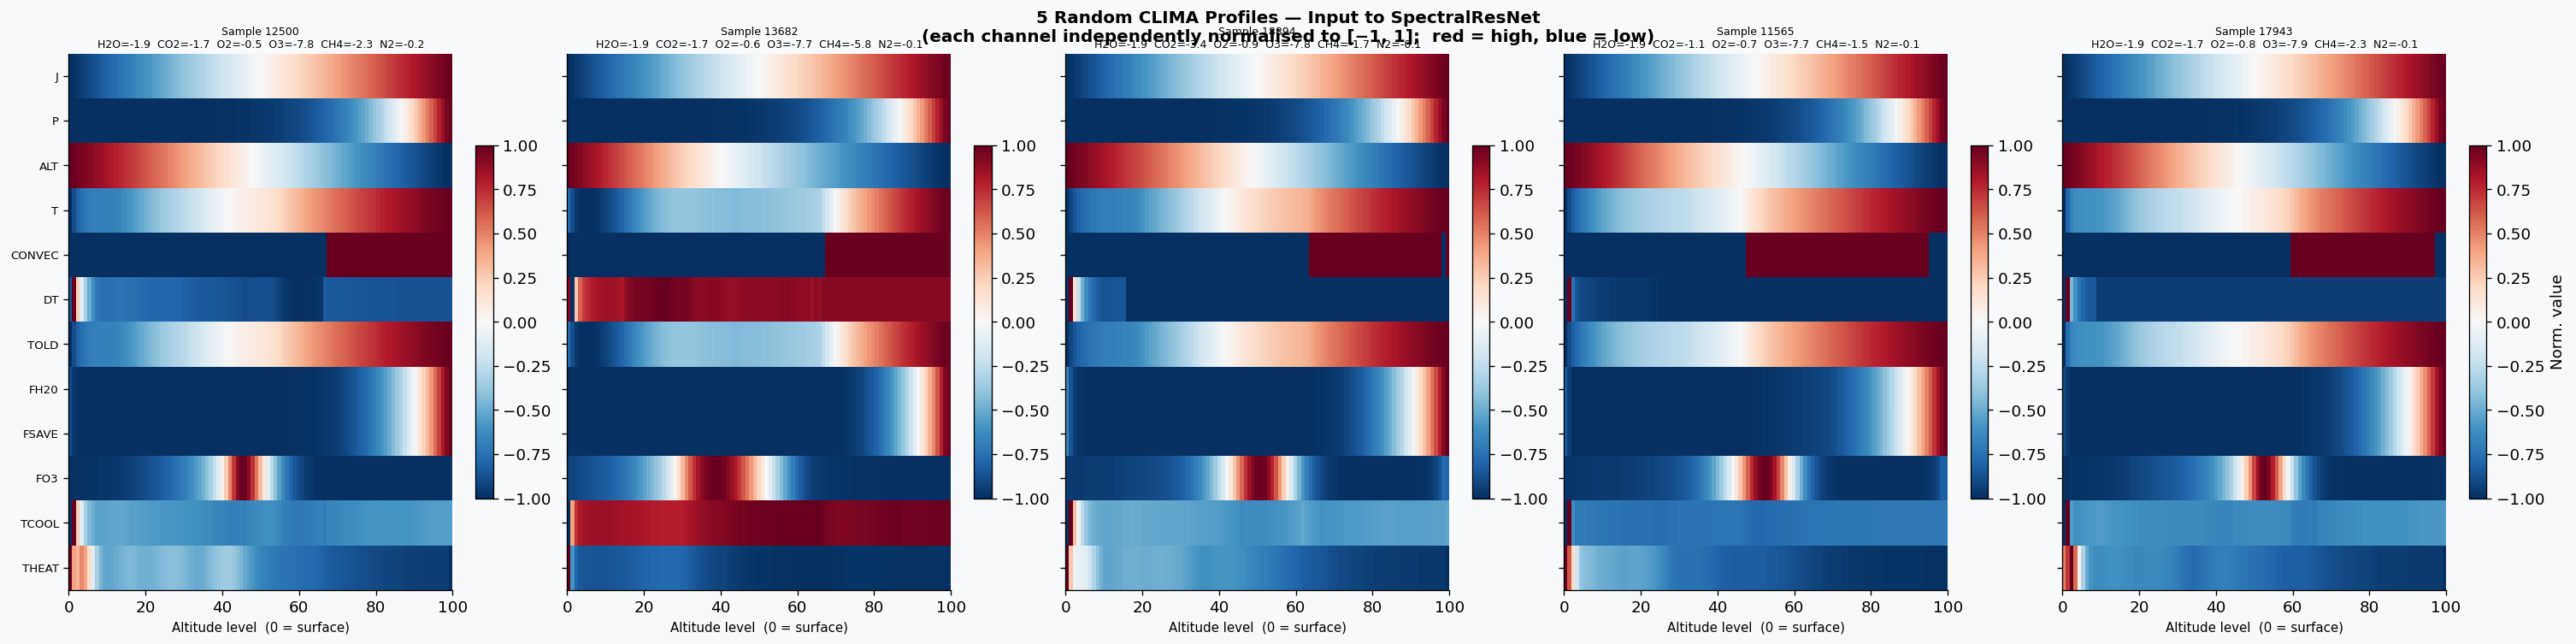

In [43]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import TwoSlopeNorm

DATA_DIR = ROOT / 'inara_data' / 'processed'

spectra    = np.load(DATA_DIR / 'spectra.npy')     # (N, 12, 101)
molecules  = np.load(DATA_DIR / 'molecules.npy')   # (N, 12)
altitude   = np.load(DATA_DIR / 'wavelengths.npy') # (101,) km

with open(DATA_DIR / 'dataset_info.json') as f:
    info = json.load(f)
CLIMA_NAMES = info['clima_channels']

# Pick 5 diverse samples — spread across the dataset
rng        = np.random.default_rng(7)
sample_idx = rng.choice(len(spectra), size=5, replace=False)

N_SAMPLES  = len(sample_idx)
fig, axes  = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 5, 6),
                           constrained_layout=True)
fig.patch.set_facecolor('#F8F9FA')

for col, idx in enumerate(sample_idx):
    ax  = axes[col]
    img = spectra[idx]          # (12, 101)

    # Per-channel normalise to [-1, 1] so all channels are visible on the same scale
    ch_min = img.min(axis=1, keepdims=True)
    ch_max = img.max(axis=1, keepdims=True)
    denom  = np.where((ch_max - ch_min) < 1e-10, 1.0, ch_max - ch_min)
    img_norm = 2 * (img - ch_min) / denom - 1   # → [-1, 1] per channel

    im = ax.imshow(img_norm, aspect='auto', cmap='RdBu_r',
                   vmin=-1, vmax=1,
                   extent=[altitude[0], altitude[-1], 11.5, -0.5])

    ax.set_xlabel('Altitude level  (0 = surface)', fontsize=9)
    ax.set_yticks(range(12))
    ax.set_yticklabels(CLIMA_NAMES, fontsize=8)
    if col > 0:
        ax.set_yticklabels([])

    # Molecule abundances as title annotation
    mol_lines = '  '.join(
        f'{m}={molecules[idx, i]:.1f}' for i, m in enumerate(MOLECULE_NAMES[:6])
    )
    ax.set_title(f'Sample {idx}\n{mol_lines}', fontsize=7.5, pad=4)

    plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.02,
                 label='Norm. value' if col == N_SAMPLES - 1 else '')

fig.suptitle(
    '5 Random CLIMA Profiles — Input to SpectralResNet\n'
    '(each channel independently normalised to [−1, 1];  red = high, blue = low)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.show()

## 1. Load Models and Pre-computed Results

In [44]:
# ── Load Random Forest ──────────────────────────────────────────────
rf_model = BaselineModel.load(MODELS_DIR / 'baseline_rf.joblib')
print(f'RF model loaded — {len(rf_model.models)} per-molecule estimators')
for mol, m in rf_model.models.items():
    print(f'  {mol:5s}: {m.n_estimators} trees, max_depth={m.max_depth}')

# ── Load ResNet ─────────────────────────────────────────────────────
# Detect in_channels from checkpoint (stem.0.weight shape[1]: 3=PSG, 12=INARA ATMOS)
state  = torch.load(MODELS_DIR / 'spectral_resnet.pt', map_location='cpu')
_in_ch = state['stem.0.weight'].shape[1]
print(f'\nDetected in_channels={_in_ch} from checkpoint')

resnet = SpectralResNet(head_configs=MOLECULE_HEAD_CONFIGS, in_channels=_in_ch)
resnet.load_state_dict(state)
resnet.eval()
print(f'ResNet loaded — {resnet.count_parameters():,} trainable parameters')

# ── Pre-computed results ─────────────────────────────────────────────
y_true      = np.load(RESULTS_DIR / 'test_targets.npy')       # (526, 12)
rf_pred     = np.load(RESULTS_DIR / 'baseline_test_pred.npy') # (526, 12)
deep_pred   = np.load(RESULTS_DIR / 'deep_test_pred.npy')     # (526, 12)
rf_metrics  = pd.read_csv(RESULTS_DIR / 'baseline_test_metrics.csv')
deep_metrics= pd.read_csv(RESULTS_DIR / 'deep_test_metrics.csv')
history     = pd.read_csv(RESULTS_DIR / 'deep_training_history.csv')
comparison  = pd.read_csv(RESULTS_DIR / 'model_comparison.csv')

print(f'\nTest set: {y_true.shape[0]} samples, {y_true.shape[1]} molecules')
print(f'Training history: {len(history)} epochs recorded')

/opt/anaconda3/envs/ML/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/ML/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


RF model loaded — 12 per-molecule estimators
  H2O  : 300 trees, max_depth=20
  CO2  : 200 trees, max_depth=12
  O2   : 200 trees, max_depth=12
  O3   : 300 trees, max_depth=18
  CH4  : 300 trees, max_depth=20
  N2   : 150 trees, max_depth=10
  N2O  : 300 trees, max_depth=18
  CO   : 300 trees, max_depth=18
  H2   : 300 trees, max_depth=16
  H2S  : 400 trees, max_depth=20
  SO2  : 400 trees, max_depth=22
  NH3  : 400 trees, max_depth=22

Detected in_channels=12 from checkpoint
ResNet loaded — 5,029,772 trainable parameters

Test set: 18648 samples, 12 molecules
Training history: 150 epochs recorded


## 2. Training History — SpectralResNet Loss Curve

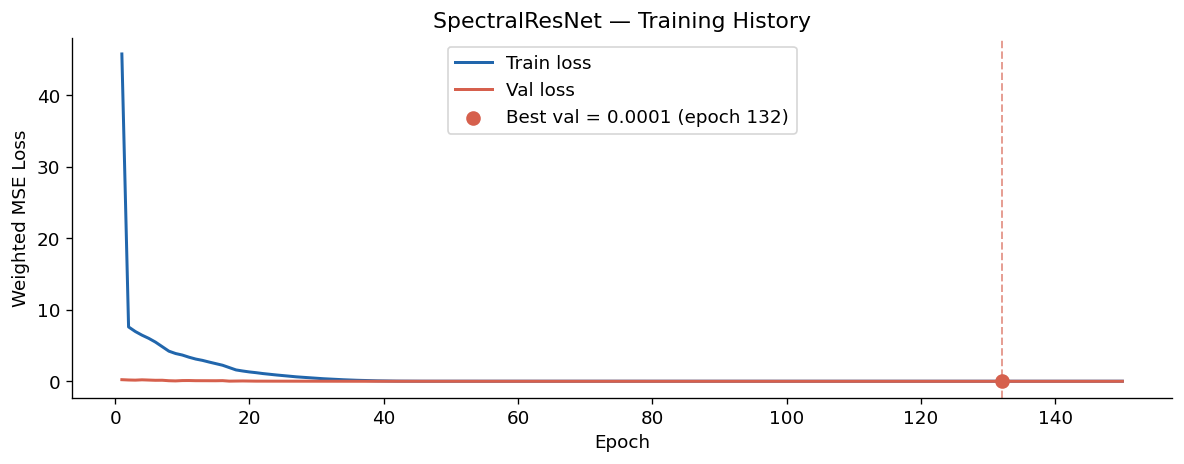

In [45]:
fig, ax = plt.subplots(figsize=(10, 4))

epochs = np.arange(1, len(history) + 1)
ax.plot(epochs, history['train_loss'], label='Train loss', color='#2166AC', lw=1.8)
ax.plot(epochs, history['val_loss'],   label='Val loss',   color='#D6604D', lw=1.8)

best_epoch = history['val_loss'].idxmin() + 1
best_val   = history['val_loss'].min()
ax.axvline(best_epoch, color='#D6604D', ls='--', lw=1.2, alpha=0.6)
ax.scatter([best_epoch], [best_val], color='#D6604D', zorder=5, s=60,
           label=f'Best val = {best_val:.4f} (epoch {best_epoch})')

ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted MSE Loss')
ax.set_title('SpectralResNet — Training History')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Model Comparison — R² per Molecule

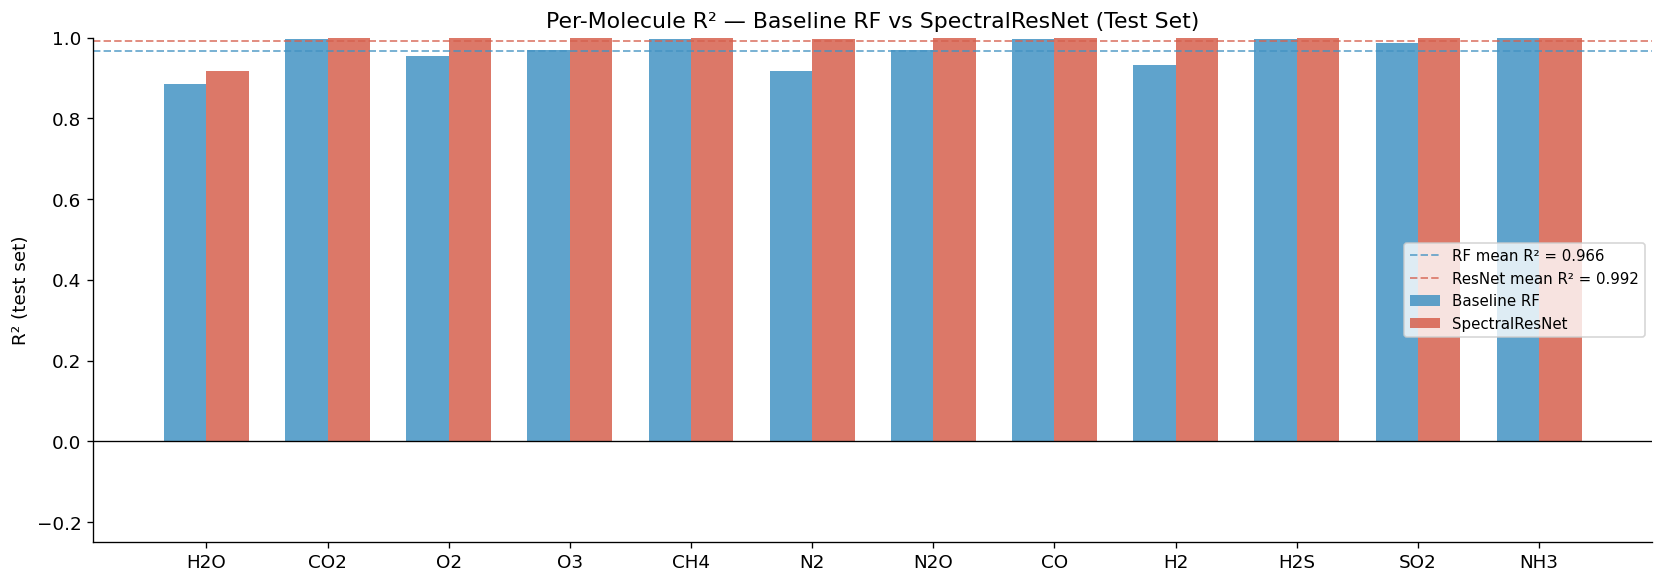

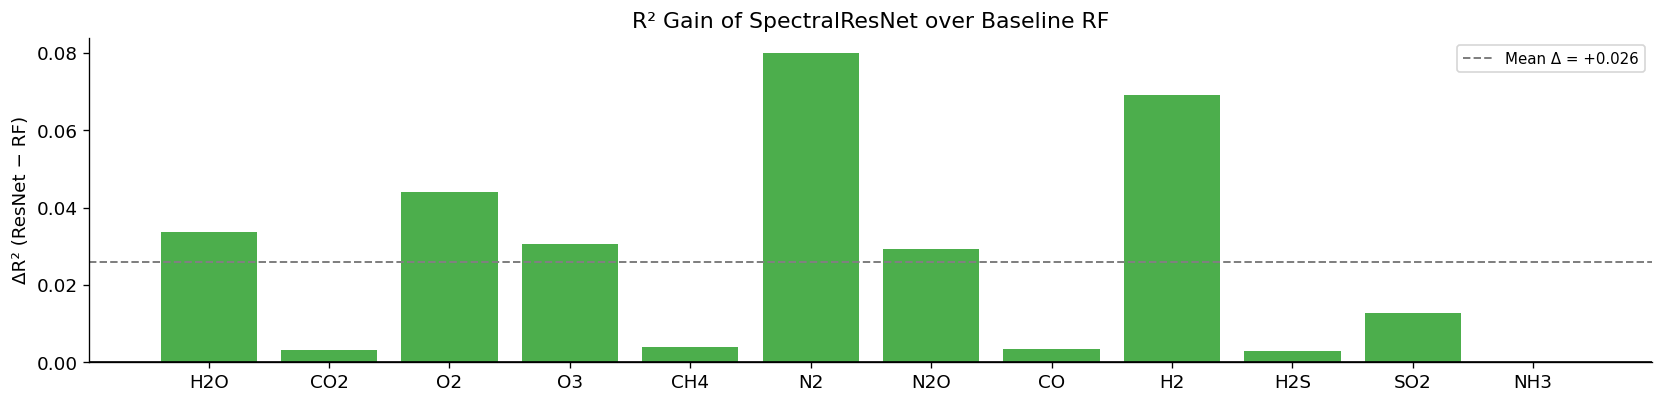

In [46]:
# Filter out MEAN row for per-molecule bars; keep MEAN for annotation
cmp = comparison[comparison['molecule'] != 'MEAN'].copy()
mean_row = comparison[comparison['molecule'] == 'MEAN'].iloc[0]

x = np.arange(len(cmp))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars_rf   = ax.bar(x - width/2, cmp['Baseline_R2'],  width, label='Baseline RF',   color='#4393C3', alpha=0.85)
bars_deep = ax.bar(x + width/2, cmp['DeepModel_R2'], width, label='SpectralResNet', color='#D6604D', alpha=0.85)

ax.axhline(0, color='black', lw=0.8)
ax.axhline(mean_row['Baseline_R2'],  color='#4393C3', ls='--', lw=1.2, alpha=0.7,
           label=f'RF mean R² = {mean_row["Baseline_R2"]:.3f}')
ax.axhline(mean_row['DeepModel_R2'], color='#D6604D', ls='--', lw=1.2, alpha=0.7,
           label=f'ResNet mean R² = {mean_row["DeepModel_R2"]:.3f}')

ax.set_xticks(x)
ax.set_xticklabels(cmp['molecule'])
ax.set_ylabel('R² (test set)')
ax.set_title('Per-Molecule R² — Baseline RF vs SpectralResNet (Test Set)')
ax.legend(fontsize=9)
ax.set_ylim(-0.25, 1.0)
plt.tight_layout()
plt.show()

# Delta R²
fig2, ax2 = plt.subplots(figsize=(14, 3.5))
colors = ['#2CA02C' if d >= 0 else '#D62728' for d in cmp['Delta_R2']]
ax2.bar(x, cmp['Delta_R2'], color=colors, alpha=0.85)
ax2.axhline(0, color='black', lw=1)
ax2.axhline(mean_row['Delta_R2'], color='grey', ls='--', lw=1.2,
            label=f'Mean Δ = {mean_row["Delta_R2"]:+.3f}')
ax2.set_xticks(x)
ax2.set_xticklabels(cmp['molecule'])
ax2.set_ylabel('ΔR² (ResNet − RF)')
ax2.set_title('R² Gain of SpectralResNet over Baseline RF')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Predicted vs Actual — All 12 Molecules

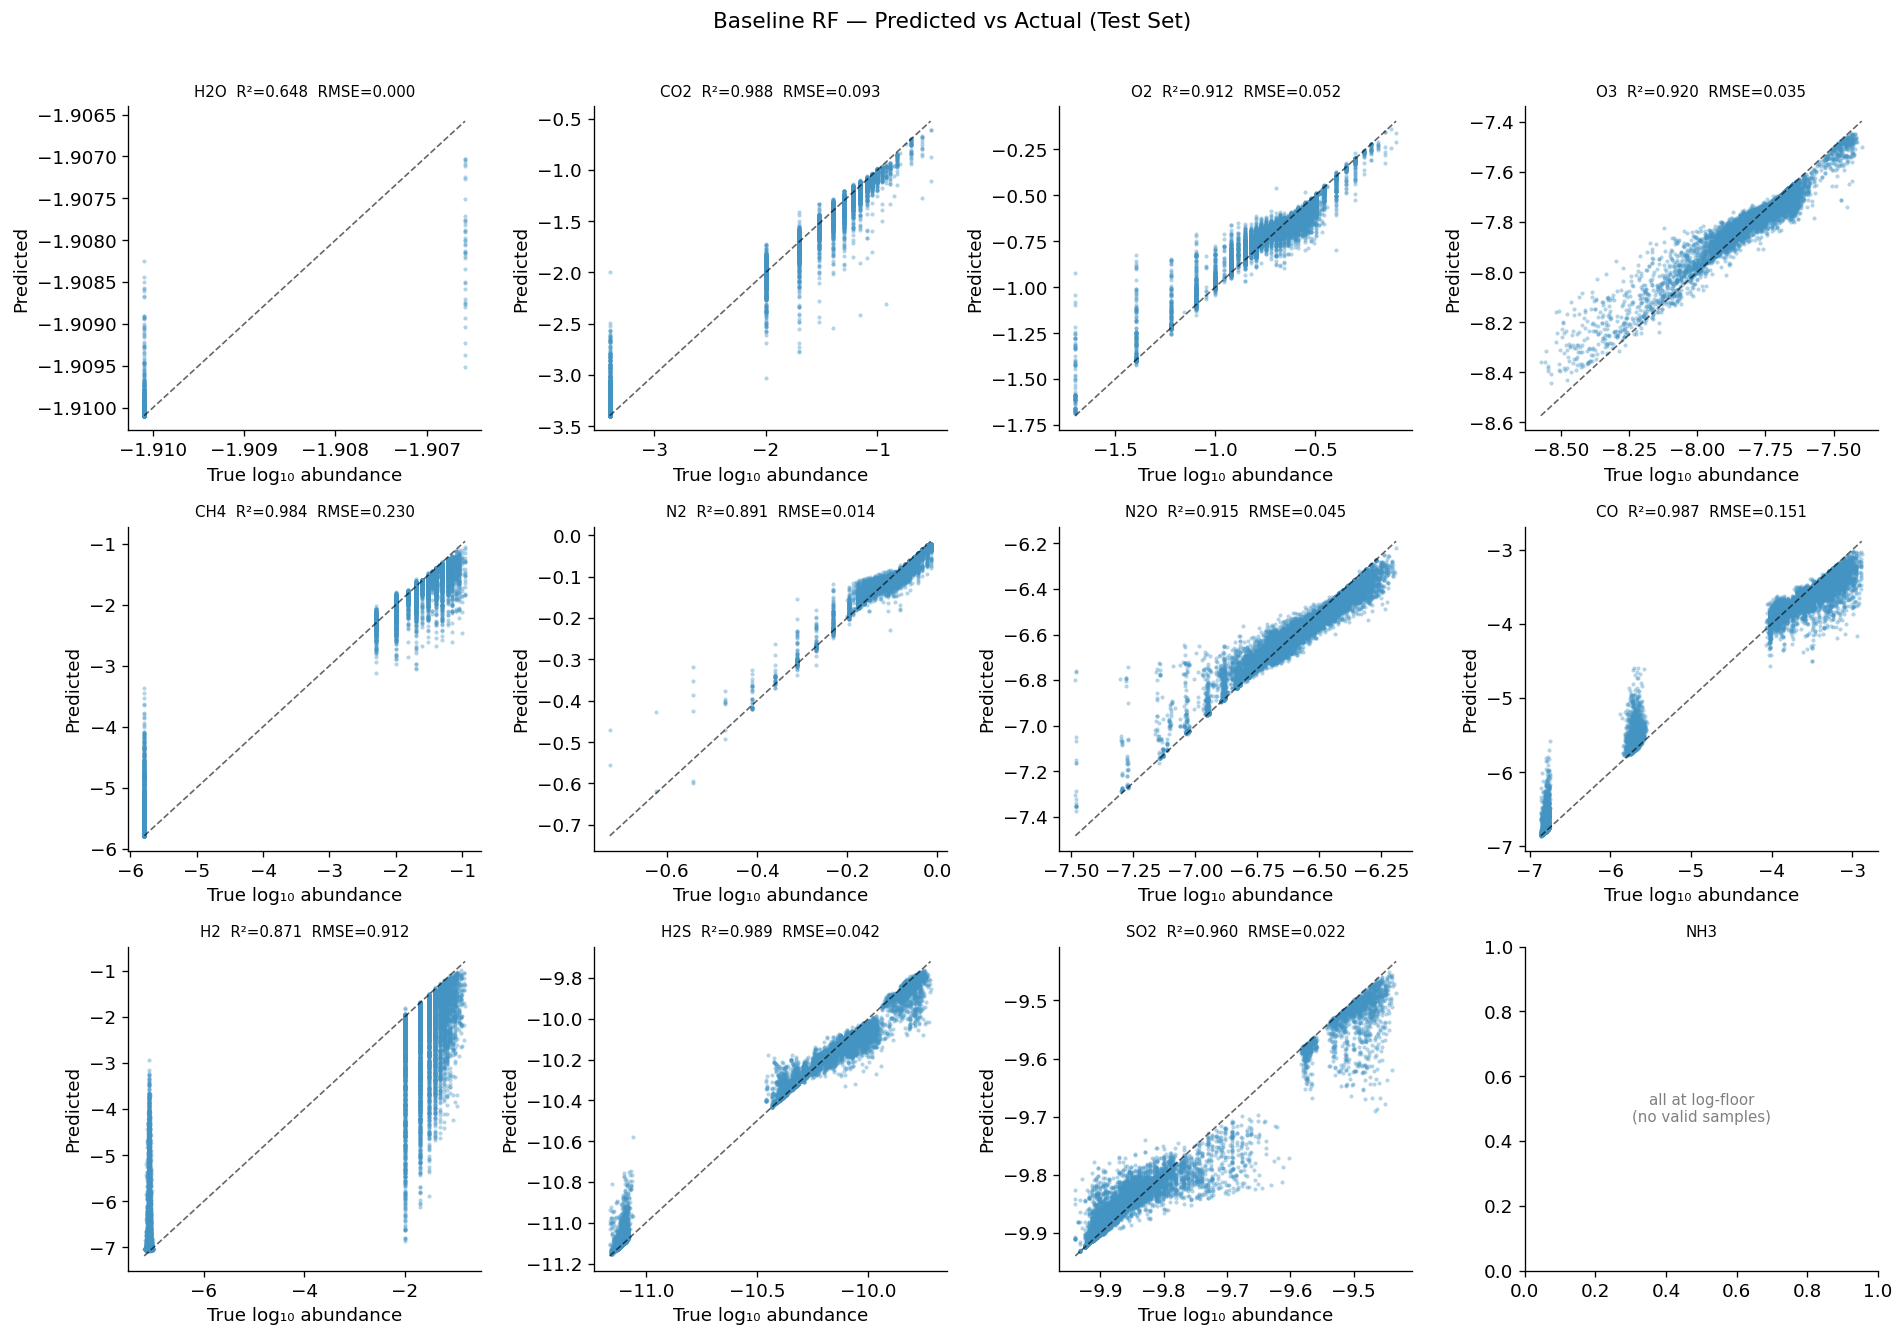

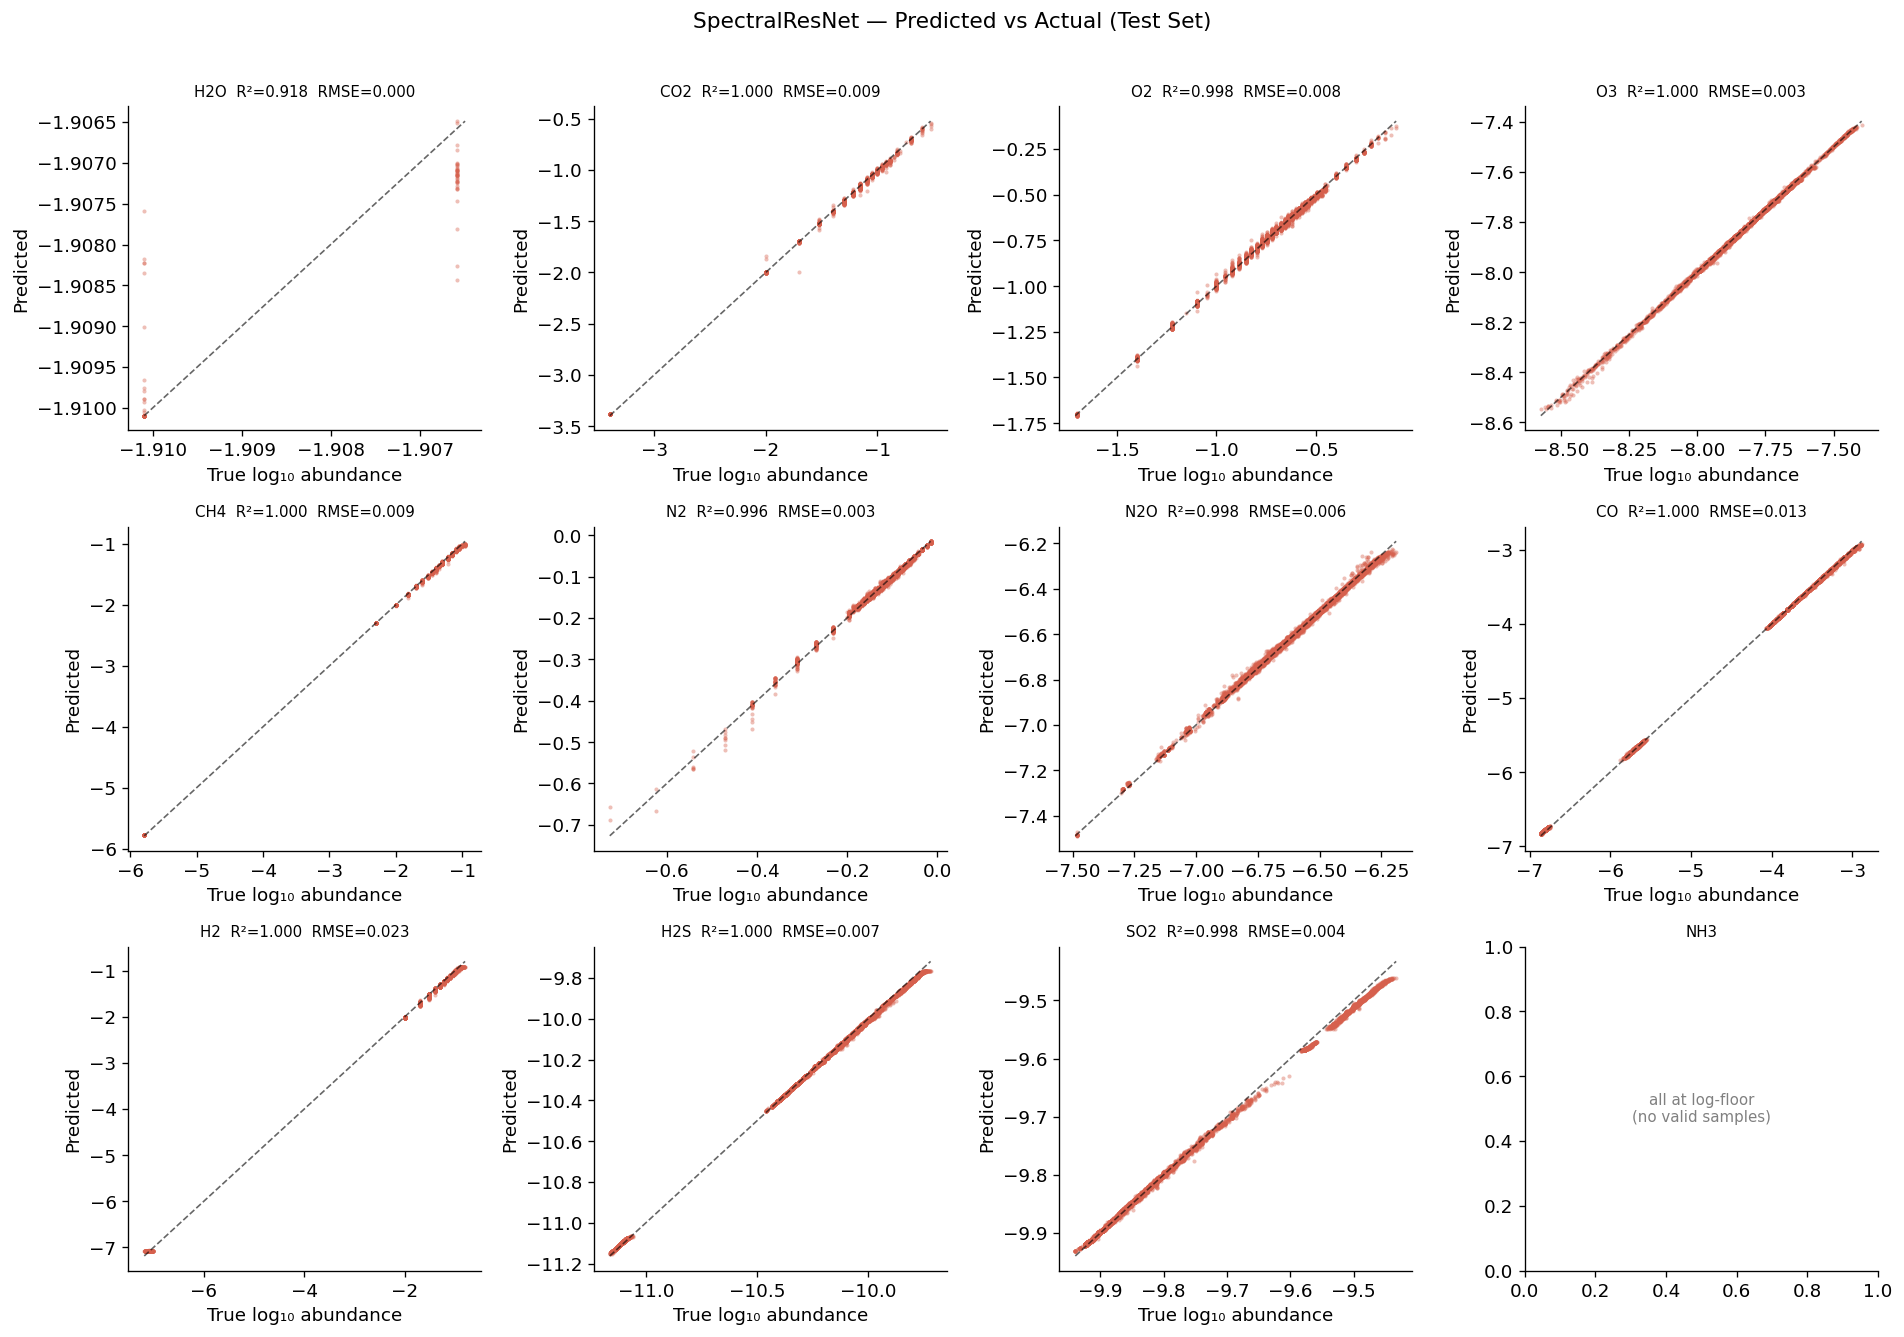

In [47]:
FLOOR = -40.0

def scatter_grid(y_true, y_pred, title, color, metrics_df):
    fig, axes = plt.subplots(3, 4, figsize=(16, 11))
    axes = axes.flatten()

    for i, (ax, mol) in enumerate(zip(axes, MOLECULE_NAMES)):
        yt, yp = y_true[:, i], y_pred[:, i]
        valid  = yt > FLOOR + 0.5

        if valid.sum() == 0:
            ax.text(0.5, 0.5, 'all at log-floor\n(no valid samples)',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=9, color='grey')
            ax.set_title(mol, fontsize=9)
            continue

        yt_v, yp_v = yt[valid], yp[valid]
        ax.scatter(yt_v, yp_v, s=6, alpha=0.4, color=color, linewidths=0)

        lo = min(yt_v.min(), yp_v.min())
        hi = max(yt_v.max(), yp_v.max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.6)

        row = metrics_df[metrics_df['molecule'] == mol].iloc[0]
        ax.set_title(f'{mol}  R²={row["R2"]:.3f}  RMSE={row["RMSE"]:.3f}', fontsize=9)
        ax.set_xlabel('True log₁₀ abundance')
        ax.set_ylabel('Predicted')

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

scatter_grid(y_true, rf_pred,   'Baseline RF — Predicted vs Actual (Test Set)',
             '#4393C3', rf_metrics)
scatter_grid(y_true, deep_pred, 'SpectralResNet — Predicted vs Actual (Test Set)',
             '#D6604D', deep_metrics)

## 5. Residual Distributions — Error Analysis

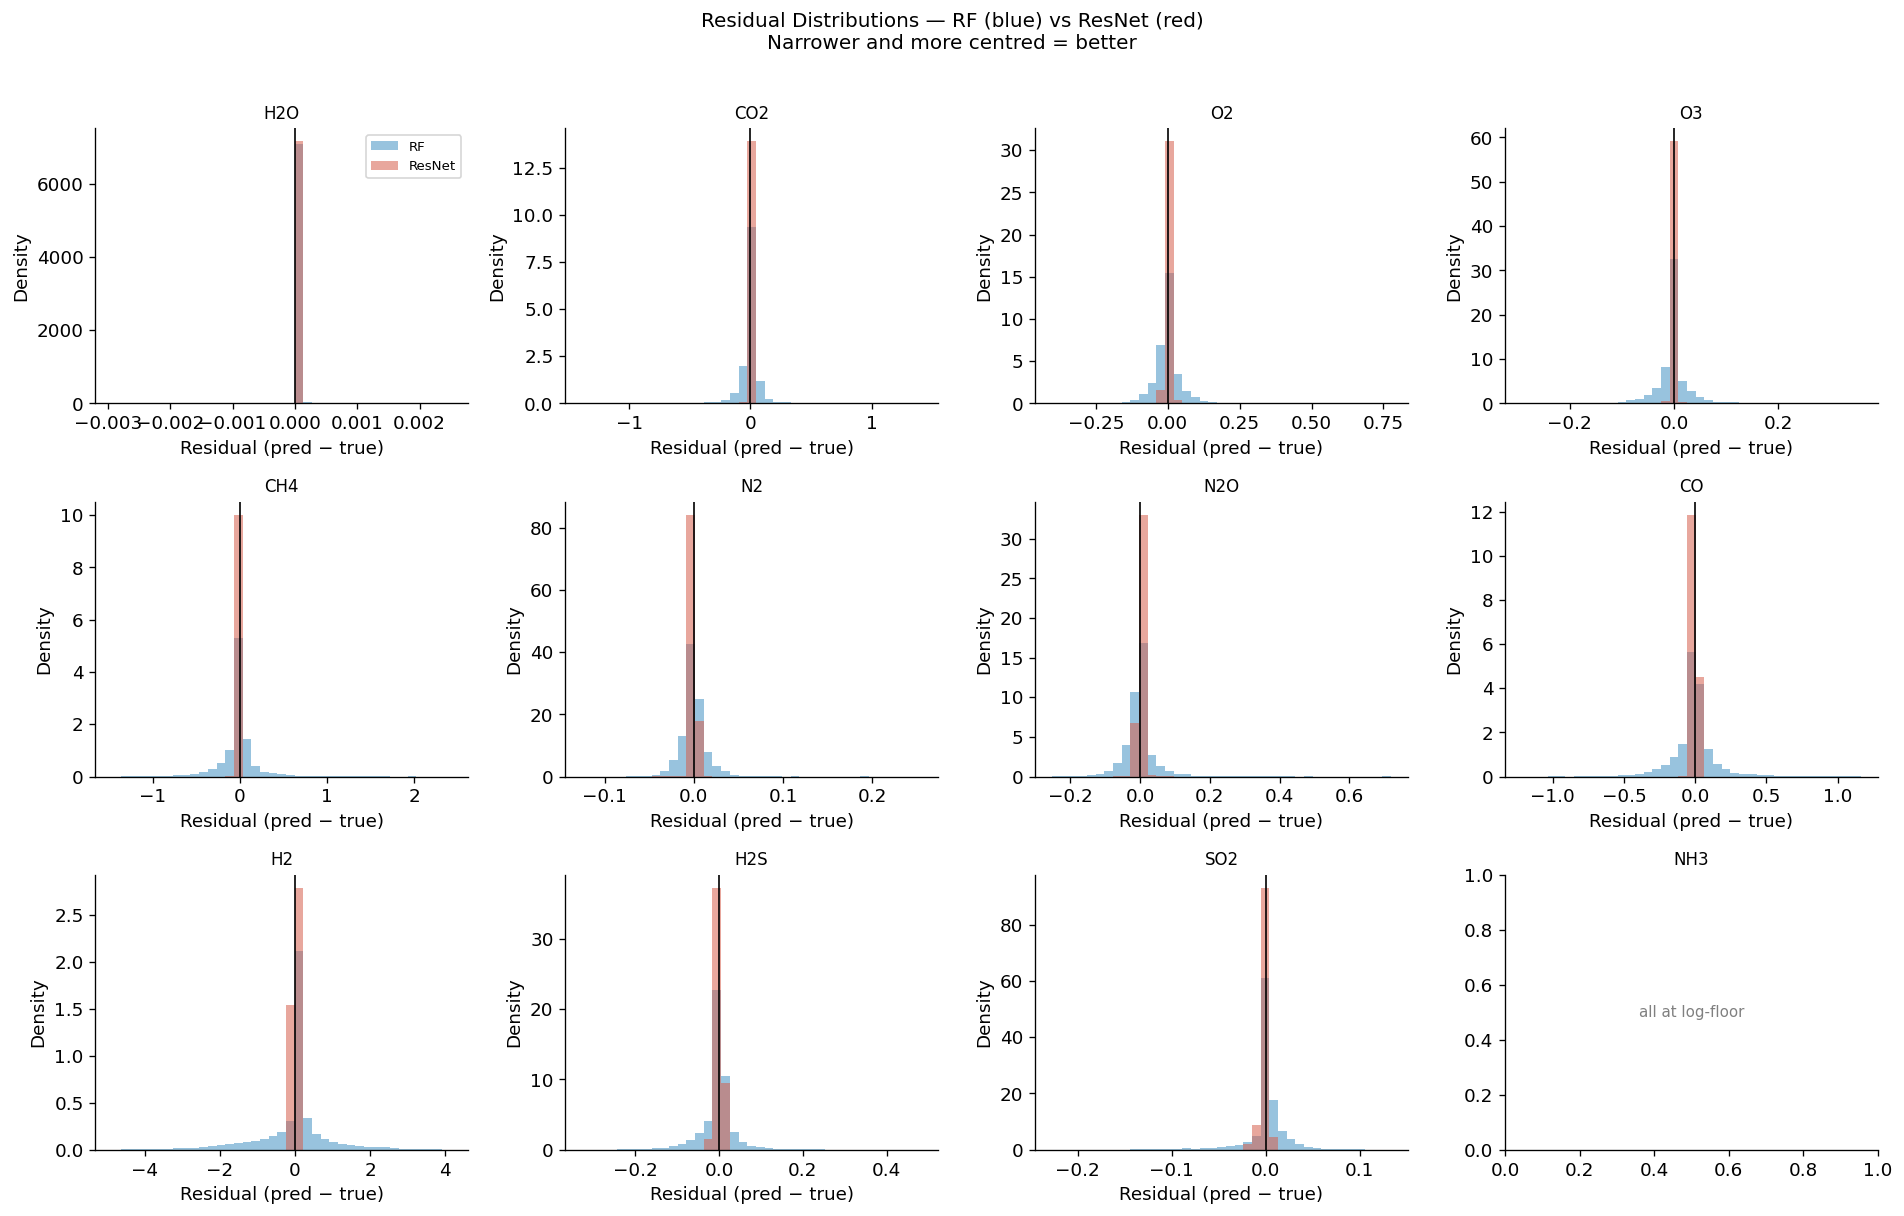

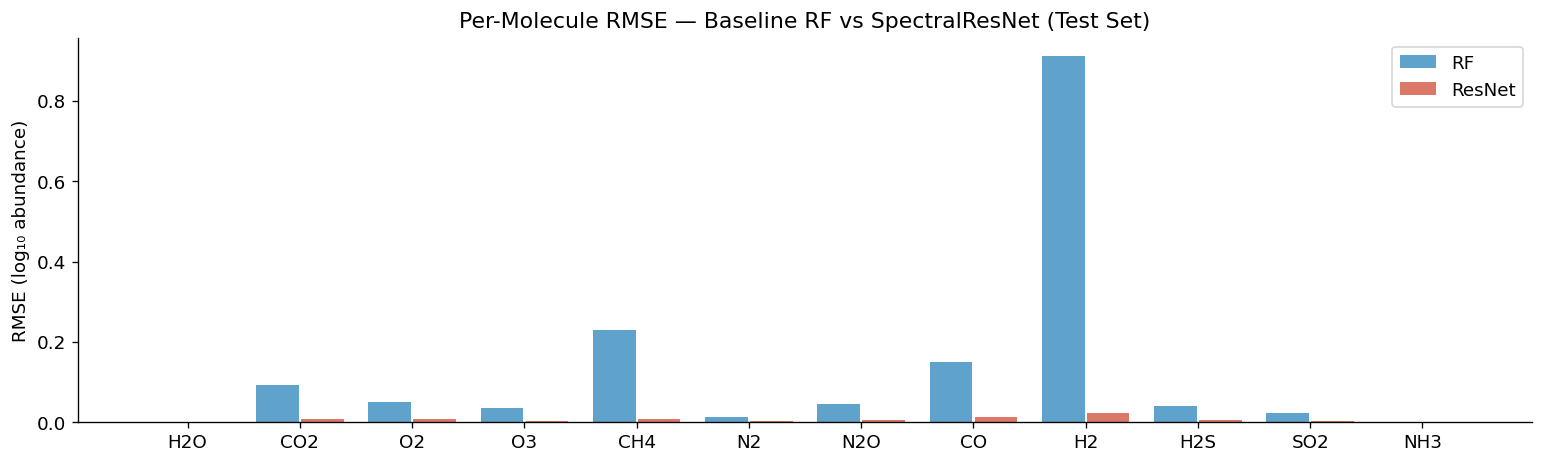

In [48]:
FLOOR = -40.0

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, (ax, mol) in enumerate(zip(axes, MOLECULE_NAMES)):
    yt    = y_true[:, i]
    valid = yt > FLOOR + 0.5

    if valid.sum() == 0:
        ax.text(0.5, 0.5, 'all at log-floor', ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='grey')
        ax.set_title(mol, fontsize=10)
        continue

    res_rf   = rf_pred[valid, i]   - yt[valid]
    res_deep = deep_pred[valid, i] - yt[valid]

    lo   = min(res_rf.min(), res_deep.min())
    hi   = max(res_rf.max(), res_deep.max())
    bins = np.linspace(lo, hi, 40)

    ax.hist(res_rf,   bins=bins, alpha=0.55, color='#4393C3', label='RF',     density=True)
    ax.hist(res_deep, bins=bins, alpha=0.55, color='#D6604D', label='ResNet', density=True)
    ax.axvline(0, color='black', lw=1)
    ax.set_title(mol, fontsize=10)
    ax.set_xlabel('Residual (pred − true)')
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle('Residual Distributions — RF (blue) vs ResNet (red)\n'
             'Narrower and more centred = better', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# RMSE comparison bar chart
rf_rmse   = rf_metrics[rf_metrics['molecule'] != 'MEAN'].set_index('molecule')['RMSE']
deep_rmse = deep_metrics[deep_metrics['molecule'] != 'MEAN'].set_index('molecule')['RMSE']

fig2, ax2 = plt.subplots(figsize=(13, 4))
x = np.arange(len(MOLECULE_NAMES))
ax2.bar(x - 0.2, rf_rmse[MOLECULE_NAMES],   0.38, label='RF',     color='#4393C3', alpha=0.85)
ax2.bar(x + 0.2, deep_rmse[MOLECULE_NAMES], 0.38, label='ResNet', color='#D6604D', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(MOLECULE_NAMES)
ax2.set_ylabel('RMSE (log₁₀ abundance)')
ax2.set_title('Per-Molecule RMSE — Baseline RF vs SpectralResNet (Test Set)')
ax2.legend()
plt.tight_layout()
plt.show()

## 6. RF Feature Importance — Top PCA Components per Molecule

Each RF estimator was trained on PCA-reduced spectral features. Which principal components does each molecule rely on most?

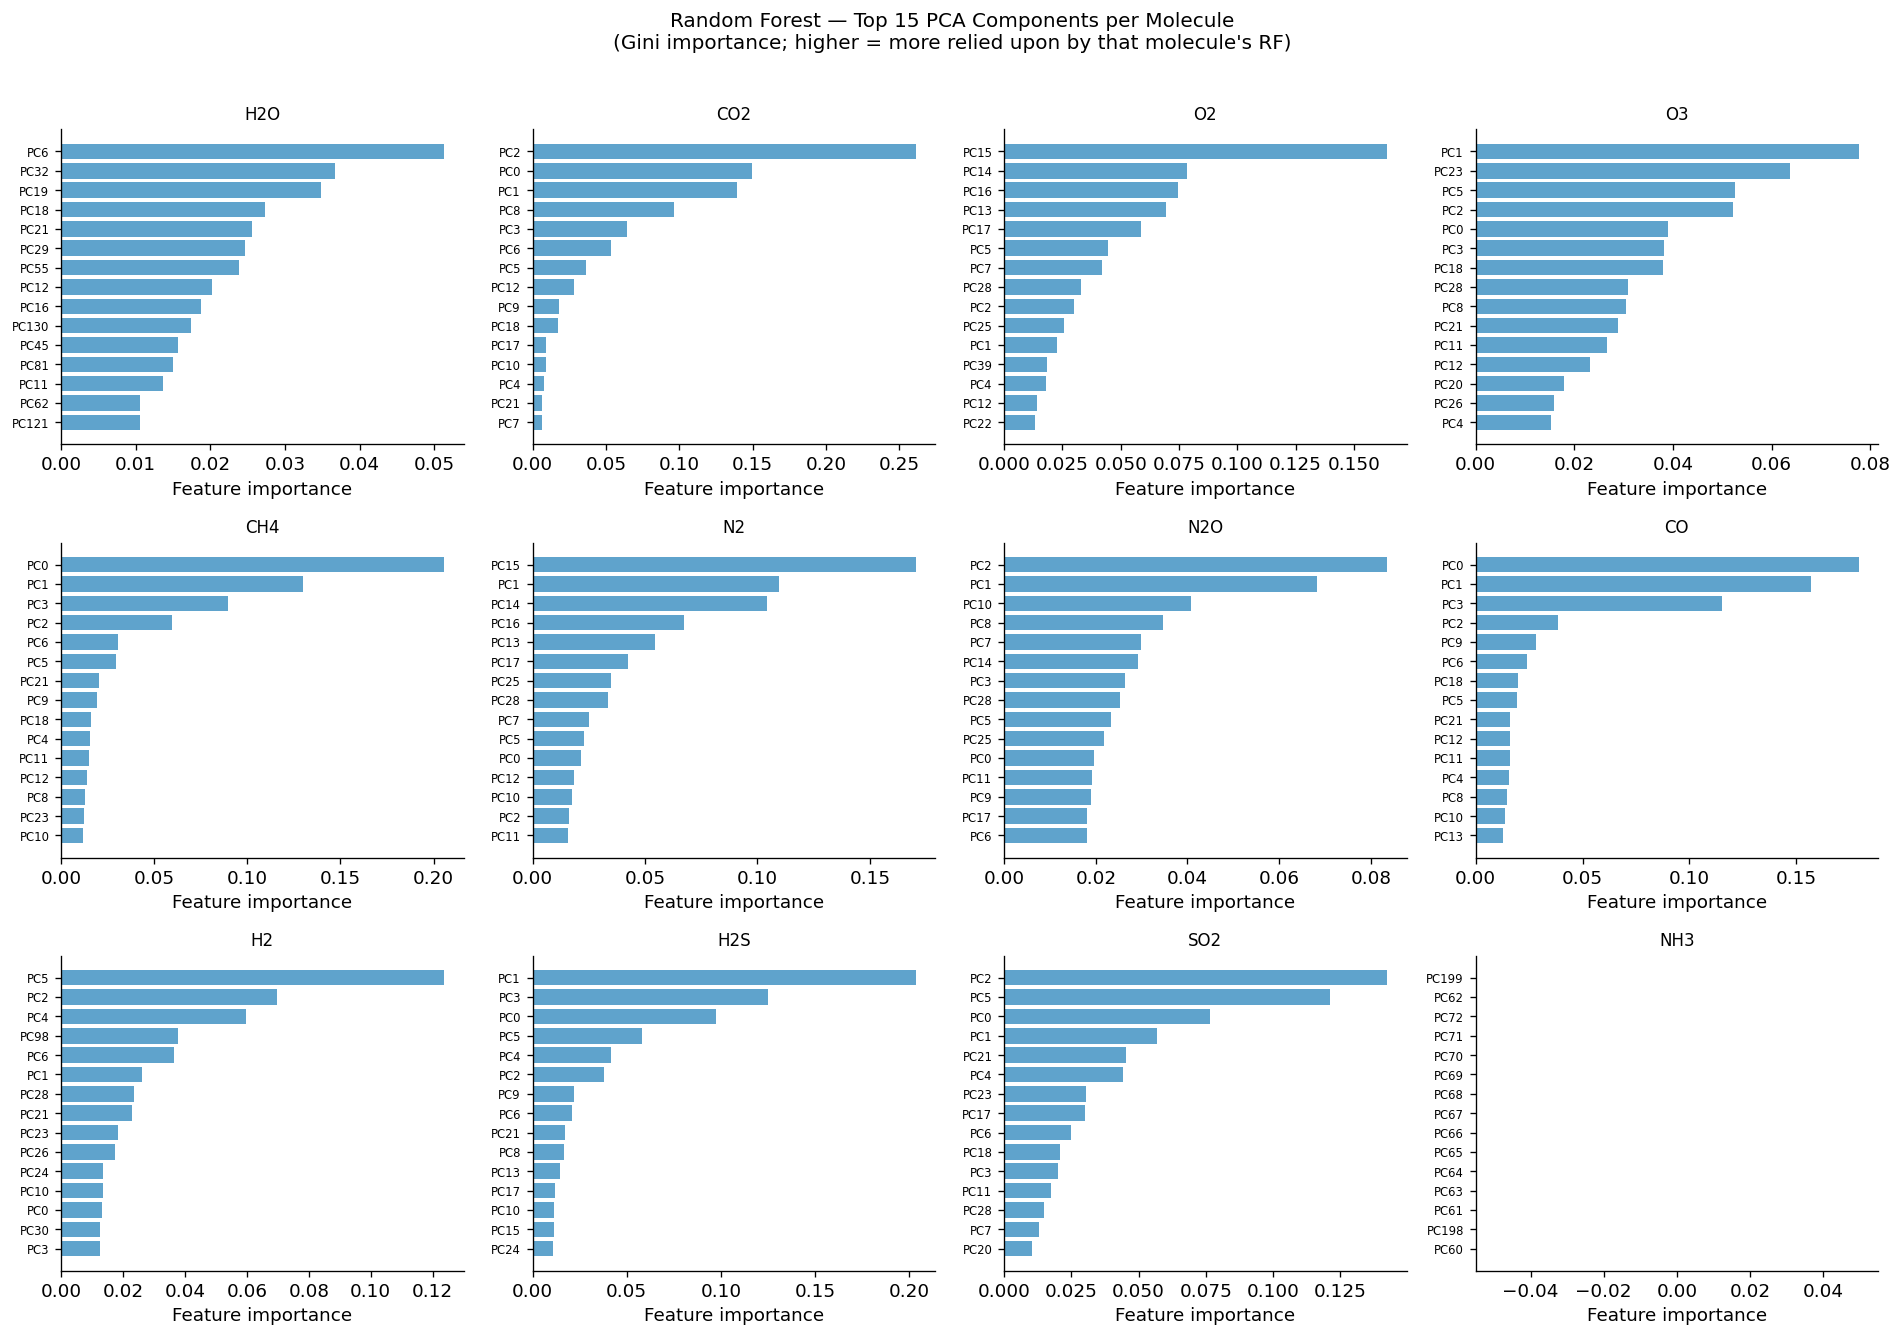

In [49]:
TOP_N = 15
importances = rf_model.feature_importance(top_n=TOP_N)

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for ax, mol in zip(axes, MOLECULE_NAMES):
    feat_imp = importances[mol]   # list of (pca_idx, importance)
    idx_arr  = [f'PC{fi}' for fi, _ in feat_imp]
    imp_arr  = [imp for _, imp in feat_imp]

    bars = ax.barh(idx_arr[::-1], imp_arr[::-1], color='#4393C3', alpha=0.85)
    ax.set_title(mol, fontsize=10)
    ax.set_xlabel('Feature importance')
    ax.tick_params(axis='y', labelsize=7)

fig.suptitle(f'Random Forest — Top {TOP_N} PCA Components per Molecule\n'
             '(Gini importance; higher = more relied upon by that molecule\'s RF)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 7. ResNet Architecture — Parameter Counts per Stage

Break down where the ~parameters live in the SpectralResNet.

Total trainable parameters: 5,029,772

Stage                               Params   % Total
------------------------------------------------------
Stem (Conv1d→64)                     8,576      0.2%
Stage 1 (64→64)                     49,664      1.0%
Stage 2 (64→128)                   181,504      3.6%
Stage 3 (128→256)                  723,456     14.4%
Stage 4 (256→512)                2,888,704     57.4%
Shared FC (512→256)                131,840      2.6%
12 Molecule Heads                1,046,028     20.8%


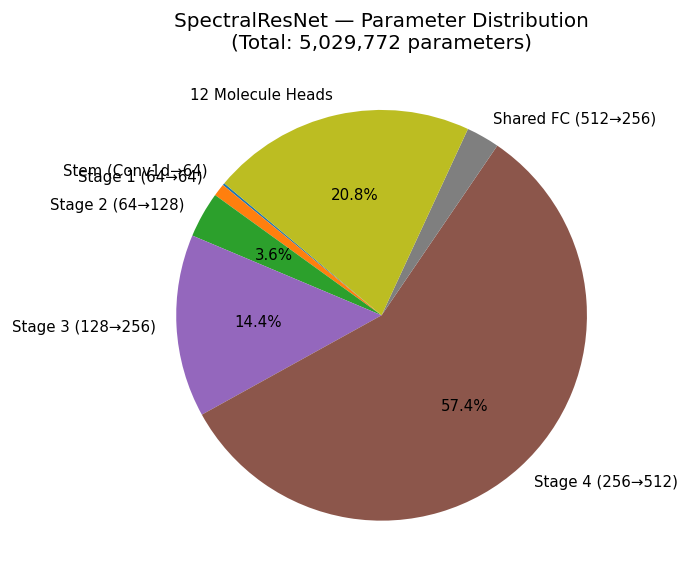


Per-molecule head parameter counts:
  H2O  : 99,585
  CO2  : 41,601
  O2   : 41,601
  O3   : 99,585
  CH4  : 99,585
  N2   : 41,601
  N2O  : 99,585
  CO   : 99,585
  H2   : 99,585
  H2S  : 107,905
  SO2  : 107,905
  NH3  : 107,905


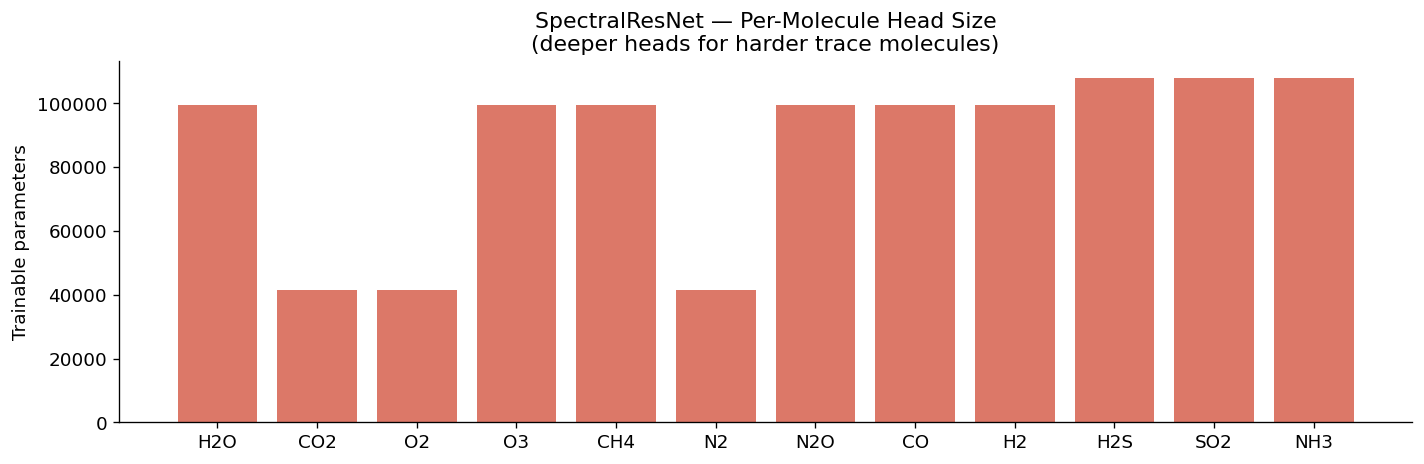

In [50]:
def count_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

stages = [
    ('Stem (Conv1d→64)', resnet.stem),
    ('Stage 1 (64→64)',  resnet.stage1),
    ('Stage 2 (64→128)', resnet.stage2),
    ('Stage 3 (128→256)', resnet.stage3),
    ('Stage 4 (256→512)', resnet.stage4),
    ('Shared FC (512→256)', resnet.shared),
    ('12 Molecule Heads', resnet.heads),
]

stage_names  = [s for s, _ in stages]
stage_params = [count_params(m) for _, m in stages]
total_params = resnet.count_parameters()

print(f'Total trainable parameters: {total_params:,}\n')
print(f'{"Stage":<30s}  {"Params":>10s}  {"% Total":>8s}')
print('-' * 54)
for name, n in zip(stage_names, stage_params):
    print(f'{name:<30s}  {n:>10,}  {100*n/total_params:>7.1f}%')

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 0.85, len(stages)))
wedges, texts, autotexts = ax.pie(
    stage_params,
    labels=stage_names,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    startangle=140,
    textprops={'fontsize': 9},
)
ax.set_title(f'SpectralResNet — Parameter Distribution\n'
             f'(Total: {total_params:,} parameters)', fontsize=12)
plt.tight_layout()
plt.show()

# Per-molecule head breakdown
print('\nPer-molecule head parameter counts:')
head_names, head_params = [], []
for mol in MOLECULE_NAMES:
    n = count_params(resnet.heads[mol])
    head_names.append(mol)
    head_params.append(n)
    print(f'  {mol:5s}: {n:,}')

fig2, ax2 = plt.subplots(figsize=(12, 4))
ax2.bar(head_names, head_params, color='#D6604D', alpha=0.85)
ax2.set_ylabel('Trainable parameters')
ax2.set_title('SpectralResNet — Per-Molecule Head Size\n'
              '(deeper heads for harder trace molecules)')
plt.tight_layout()
plt.show()

## 8. ResNet Architecture Diagram — Horizontal Layout

End-to-end view: input CLIMA profile → backbone stages → shared projection → 12 per-molecule heads → log₁₀ abundances.

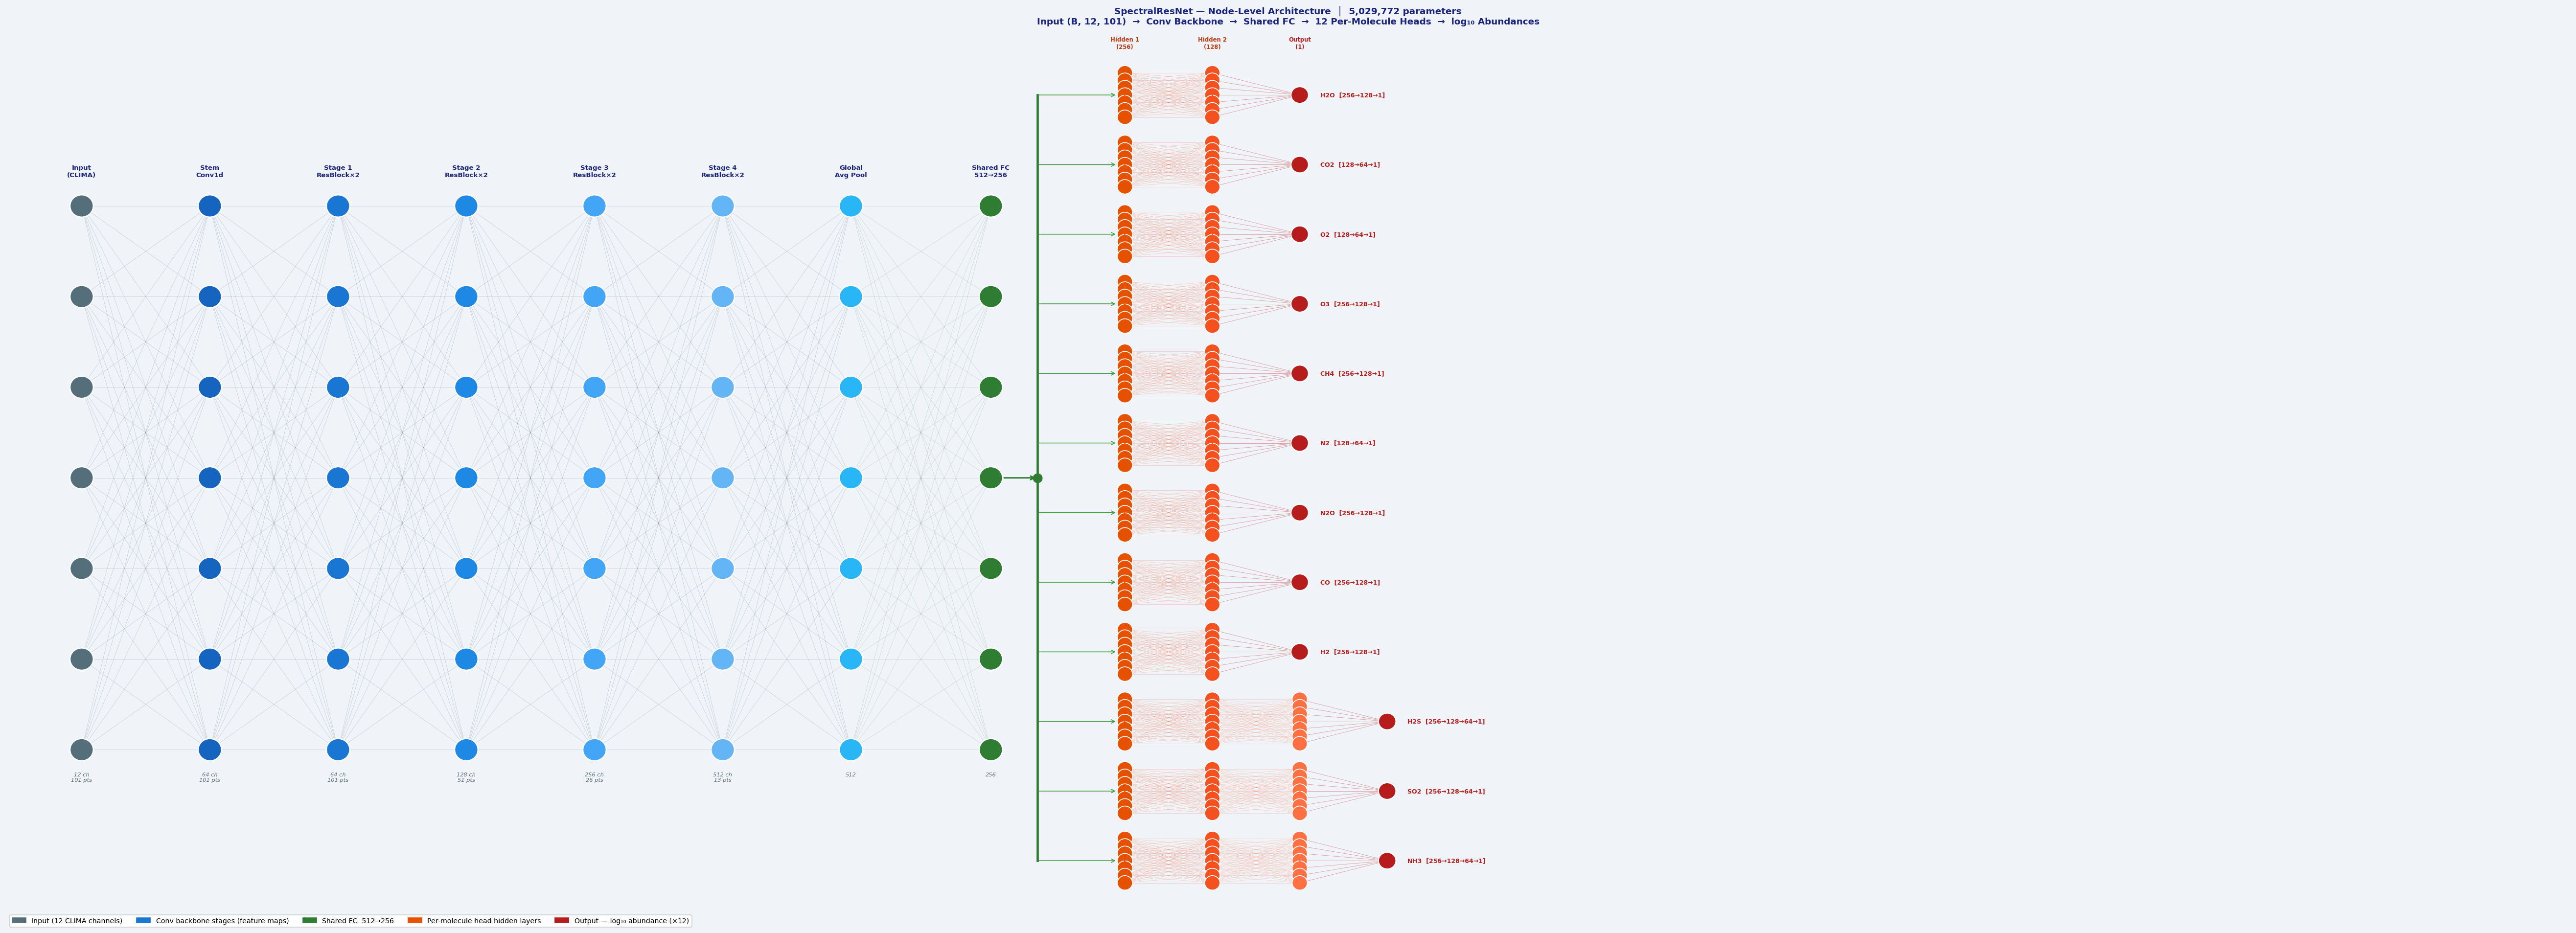

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

MAX_SHOWN  = 7      # max neuron circles drawn per backbone column
DOT_R      = 0.20
FIG_W, FIG_H = 44, 16
MID_Y      = FIG_H / 2

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.set_xlim(0, FIG_W); ax.set_ylim(0, FIG_H); ax.axis('off')
fig.patch.set_facecolor('#F0F4F8'); ax.set_facecolor('#F0F4F8')

# ── helpers ────────────────────────────────────────────────────────────────────
def node_ys(n, cy, spread):
    return np.linspace(cy + spread/2, cy - spread/2, min(n, MAX_SHOWN))

def draw_column(ax, cx, n, color, label, sublabel, cy=MID_Y, spread=9.8, r=DOT_R, fs=8):
    ys = node_ys(n, cy, spread)
    for y in ys:
        ax.add_patch(plt.Circle((cx, y), r, color=color, ec='white', lw=1.4, zorder=4))
    if n > MAX_SHOWN:
        ax.text(cx, cy, '⋮', ha='center', va='center', fontsize=15,
                color=color, fontweight='bold', zorder=5)
    ax.text(cx, ys[0]  + r + 0.30, label,    ha='center', va='bottom',
            fontsize=fs, fontweight='bold', color='#1A237E', zorder=5)
    ax.text(cx, ys[-1] - r - 0.20, sublabel, ha='center', va='top',
            fontsize=6.8, color='#546E7A', style='italic', zorder=5)
    return ys

def connect(ax, cx1, ys1, cx2, ys2, color='#90A4AE', alpha=0.15, lw=0.5):
    for y1 in ys1:
        for y2 in ys2:
            ax.plot([cx1, cx2], [y1, y2], color=color, alpha=alpha, lw=lw, zorder=1)

# ── Backbone columns ───────────────────────────────────────────────────────────
BACKBONE = [
    (1.3,  12,  '#546E7A', 'Input\n(CLIMA)',      '12 ch\n101 pts',  '#78909C'),
    (3.5,  64,  '#1565C0', 'Stem\nConv1d',        '64 ch\n101 pts',  "#092634"),
    (5.7,  64,  '#1976D2', 'Stage 1\nResBlock×2', '64 ch\n101 pts',  '#092634'),
    (7.9,  128, '#1E88E5', 'Stage 2\nResBlock×2', '128 ch\n51 pts',  '#092634'),
    (10.1, 256, '#42A5F5', 'Stage 3\nResBlock×2', '256 ch\n26 pts',  '#092634'),
    (12.3, 512, '#64B5F6', 'Stage 4\nResBlock×2', '512 ch\n13 pts',  '#092634'),
    (14.5, 512, '#29B6F6', 'Global\nAvg Pool',    '512',             "#102934"),
    (16.9, 256, '#2E7D32', 'Shared FC\n512→256',  '256',             "#2D6030"),
]

prev_ys, prev_cx = None, None
for (cx, n, color, label, sub, conn_color) in BACKBONE:
    ys = draw_column(ax, cx, n, color, label, sub, cy=MID_Y, spread=9.8)
    if prev_ys is not None:
        connect(ax, prev_cx, prev_ys, cx, ys, color=conn_color, alpha=0.18, lw=0.45)
    prev_ys, prev_cx = ys, cx

shared_cx = BACKBONE[-1][0]

# ── Bus line: SharedFC → 12 molecule heads ─────────────────────────────────────
BUS_X    = shared_cx + 0.8
mol_mids = np.linspace(FIG_H - 1.1, 1.1, 12)

ax.plot([BUS_X, BUS_X], [mol_mids[-1], mol_mids[0]],
        color='#2E7D32', lw=2.8, zorder=2)
ax.scatter([BUS_X], [MID_Y], s=120, color='#2E7D32', zorder=5)
ax.annotate('', xy=(BUS_X, MID_Y), xytext=(shared_cx + DOT_R, MID_Y),
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=1.8), zorder=3)

# ── Head neuron columns ────────────────────────────────────────────────────────
HEAD_SPREAD = 0.80
HEAD_MAX    = 4
HEAD_R      = 0.13
COL_A   = BUS_X + 1.5
COL_B   = COL_A + 1.5
COL_C   = COL_B + 1.5
COL_OUT = COL_C + 1.5
HEAD_COLORS = ['#E65100', '#F4511E', '#FF7043']
OUT_COLOR   = '#B71C1C'

for mol, cy in zip(MOLECULE_NAMES, mol_mids):
    cfg   = MOLECULE_HEAD_CONFIGS[mol]
    hdims = cfg['hidden_dims']

    # tap from bus
    ax.annotate('', xy=(COL_A - HEAD_R, cy), xytext=(BUS_X, cy),
                arrowprops=dict(arrowstyle='->', color='#43A047', lw=1.0), zorder=2)

    col_xs_h = [COL_A, COL_B] + ([COL_C] if len(hdims) == 3 else [])

    prev_hx, prev_hys = None, None
    for hi, (hx, hdim) in enumerate(zip(col_xs_h, hdims)):
        c   = HEAD_COLORS[hi % len(HEAD_COLORS)]
        hys = node_ys(hdim, cy, HEAD_SPREAD)
        for y in hys:
            ax.add_patch(plt.Circle((hx, y), HEAD_R, color=c, ec='white', lw=1.0, zorder=4))
        if hdim > HEAD_MAX:
            ax.text(hx, cy, '⋮', ha='center', va='center', fontsize=9,
                    color=c, fontweight='bold', zorder=5)
        # column header on topmost molecule only
        if cy == mol_mids[0]:
            ax.text(hx, cy + HEAD_SPREAD/2 + HEAD_R + 0.28,
                    f'Hidden {hi+1}\n({hdim})', ha='center', va='bottom',
                    fontsize=7, fontweight='bold', color='#BF360C', zorder=5)
        if prev_hys is not None:
            connect(ax, prev_hx, prev_hys, hx, hys, color=c, alpha=0.22, lw=0.5)
        prev_hx, prev_hys = hx, hys

    # output node
    out_x = COL_OUT if len(hdims) == 3 else COL_C
    ax.add_patch(plt.Circle((out_x, cy), HEAD_R + 0.02,
                             color=OUT_COLOR, ec='white', lw=1.3, zorder=4))
    connect(ax, prev_hx, prev_hys, out_x, [cy],
            color=OUT_COLOR, alpha=0.4, lw=0.5)
    if cy == mol_mids[0]:
        ax.text(out_x, cy + HEAD_SPREAD/2 + HEAD_R + 0.28, 'Output\n(1)',
                ha='center', va='bottom', fontsize=7, fontweight='bold',
                color=OUT_COLOR, zorder=5)
    dim_str = '→'.join([str(d) for d in hdims] + ['1'])
    ax.text(out_x + 0.35, cy, f'{mol}  [{dim_str}]',
            ha='left', va='center', fontsize=7.5,
            color=OUT_COLOR, fontweight='bold', zorder=5)

# ── Legend ─────────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color='#546E7A', label='Input (12 CLIMA channels)'),
    mpatches.Patch(color='#1976D2', label='Conv backbone stages (feature maps)'),
    mpatches.Patch(color='#2E7D32', label='Shared FC  512→256'),
    mpatches.Patch(color='#E65100', label='Per-molecule head hidden layers'),
    mpatches.Patch(color='#B71C1C', label='Output — log₁₀ abundance (×12)'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=8.5,
          framealpha=0.95, ncol=5, bbox_to_anchor=(0.0, -0.01), edgecolor='#CCCCCC')

ax.set_title(
    'SpectralResNet — Node-Level Architecture  │  5,029,772 parameters\n'
    'Input (B, 12, 101)  →  Conv Backbone  →  Shared FC  →  12 Per-Molecule Heads  →  log₁₀ Abundances',
    fontsize=11, fontweight='bold', pad=12, color='#1A237E'
)

plt.tight_layout()
plt.show()

## 8. Summary Table

In [52]:
summary = comparison.copy()
summary['Baseline_RMSE'] = rf_metrics.set_index('molecule').reindex(summary['molecule'])['RMSE'].values
summary['Deep_RMSE']     = deep_metrics.set_index('molecule').reindex(summary['molecule'])['RMSE'].values
summary['Winner'] = summary.apply(
    lambda r: 'ResNet' if r['DeepModel_R2'] > r['Baseline_R2'] else 'RF',
    axis=1
)
summary.loc[summary['molecule'] == 'MEAN', 'Winner'] = ''

display_cols = ['molecule', 'Baseline_R2', 'DeepModel_R2', 'Delta_R2',
                'Baseline_RMSE', 'Deep_RMSE', 'Winner']
print(summary[display_cols].to_string(index=False, float_format='%.4f'))

molecule  Baseline_R2  DeepModel_R2  Delta_R2  Baseline_RMSE  Deep_RMSE Winner
     H2O       0.8844        0.9181    0.0338         0.0001     0.0000 ResNet
     CO2       0.9968        0.9999    0.0031         0.0926     0.0089 ResNet
      O2       0.9541        0.9981    0.0440         0.0516     0.0076 ResNet
      O3       0.9689        0.9995    0.0306         0.0354     0.0027 ResNet
     CH4       0.9959        1.0000    0.0041         0.2297     0.0091 ResNet
      N2       0.9161        0.9960    0.0799         0.0143     0.0027 ResNet
     N2O       0.9690        0.9982    0.0293         0.0448     0.0065 ResNet
      CO       0.9964        0.9999    0.0035         0.1511     0.0129 ResNet
      H2       0.9309        0.9999    0.0690         0.9121     0.0232 ResNet
     H2S       0.9968        0.9997    0.0029         0.0416     0.0069 ResNet
     SO2       0.9858        0.9984    0.0127         0.0224     0.0044 ResNet
     NH3       1.0000        1.0000    0.0000       